In [5]:
import json
import pickle
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import ks_2samp
from collections import defaultdict, Counter
import numpy as np
import pandas as pd

In [ ]:
import os
from atomica.data.pdb_utils import VOCAB
VOCAB.load_tokenizer('PS_300')
VOCAB_LEN = len(VOCAB.idx2abrv)

/n/holylabs/LABS/mzitnik_lab/Users/afang/GET


In [10]:
aa_type_color_dict = {
 '3polar': '#2E3BE8',   
 '4hydrophobic': '#55E022',
 '5aromatic': '#FFDB58',
 '1positive': '#E02121',   
 '2negative': '#CC22E0',
 "6unique": "#FFA700",
}

AA_TYPE = {
 'GLY': 'unique',
 'PRO': 'unique',
 'ALA': 'hydrophobic',
 'ILE': 'hydrophobic',
 'LEU': 'hydrophobic',
 'VAL': 'hydrophobic',
 'ASN': 'polar',
 'CYS': 'unique',
 'GLN': 'polar',
 'SER': 'polar',
 'THR': 'polar',
 'PHE': 'aromatic',
 'TYR': 'aromatic',
 'TRP': 'aromatic',
 'HIS': 'positive', # and polar, aromatic
 'ARG': 'positive',
 'LYS': 'positive',
 'ASP': 'negative',
 'GLU': 'negative',
 'MET': 'hydrophobic',
}

In [17]:
k = 5
interact_enrichment_ratios = {}

for modality in ["PL_nonredund","PRNA_nonredund","PDNA_nonredund","PP_nonredund_fixed_ids","Pion_nonredund","Ppeptide_nonredund"]:
    interact_scores_file = f"/n/holyscratch01/mzitnik_lab/afang/plip_frequency_splits_torsion_09_2024/interact_score/{modality}_test.json"
    raw_data_file = f"/n/holystore01/LABS/mzitnik_lab/Lab/afang/frequency_splits_torsion_09_2024/{modality}_test.pkl"
    
    with open(raw_data_file, 'rb') as f:
        dataset_list = pickle.load(f)
    dataset_by_id = {x['id']: x for x in dataset_list}

    interact_scores = []
    with open(interact_scores_file, "r") as f:
        for line in f.readlines():
            interact_scores.append(json.loads(line))
    interact_scores = pd.concat([pd.DataFrame(interact_scores_) for interact_scores_ in interact_scores])
    interact_scores['res_name'] = interact_scores.apply(lambda row: dataset_by_id[row['id']]['block_to_pdb_indexes'].get(row['block_idx']), axis=1)
    interact_scores['block_type'] = interact_scores.apply(lambda row: VOCAB.idx_to_abrv(dataset_by_id[row['id']]['data']['B'][row['block_idx']]), axis=1)

    print(f"{modality} num interact scores:", len(interact_scores['id'].unique()))
    print(f"{modality} num raw data:", len(dataset_by_id))
    print(f"{modality} block types", len(interact_scores['block_type'].unique()))

    # Filter for only AAs
    interact_scores = interact_scores[interact_scores['block_type'].isin(AA_TYPE.keys())]

    topk_count = []
    all_count = []
    for id in interact_scores['id'].unique():
        interact_scores_id = interact_scores[interact_scores['id'] == id].sort_values('cos_distances', ascending=True)
        if len(interact_scores_id) <= k:
            continue
        topk_blocks = interact_scores_id['block_type'].head(k).values.tolist()
        all_blocks = interact_scores_id['block_type'].values.tolist()
        topk_count.extend(topk_blocks)
        all_count.extend(all_blocks)
    
    num_topk = len(topk_count)
    num_all = len(all_count)
    topk_count = Counter(topk_count)
    all_count = Counter(all_count)

    topk_prop = {k: v/num_topk for k, v in topk_count.items()}
    all_prop = {k: v/num_all for k, v in all_count.items()}

    lor = {k: np.log10(topk_prop[k]/all_prop[k]) for k in topk_prop}
    interact_enrichment_ratios[modality.split("_")[0]] = lor

PL_nonredund num interact scores: 11100
PL_nonredund num raw data: 11100
PL_nonredund block types 183
PRNA_nonredund num interact scores: 360
PRNA_nonredund num raw data: 360
PRNA_nonredund block types 29
PDNA_nonredund num interact scores: 280
PDNA_nonredund num raw data: 280
PDNA_nonredund block types 24
PP_nonredund_fixed_ids num interact scores: 3378
PP_nonredund_fixed_ids num raw data: 11900
PP_nonredund_fixed_ids block types 20
Pion_nonredund num interact scores: 7200
Pion_nonredund num raw data: 7200
Pion_nonredund block types 34
Ppeptide_nonredund num interact scores: 820
Ppeptide_nonredund num raw data: 820
Ppeptide_nonredund block types 21


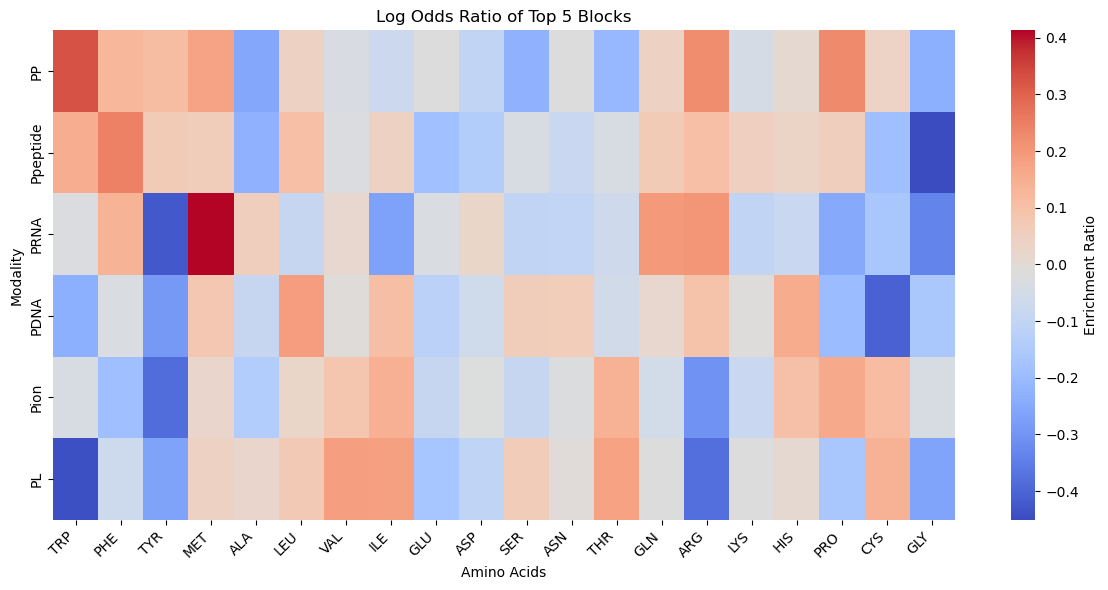

In [18]:
enrichment_df = pd.DataFrame(interact_enrichment_ratios).T

# Group the amino acids by their type for ordering in the heatmap
enrichment_df = enrichment_df.reindex(columns=sorted(enrichment_df.columns, key=lambda x: AA_TYPE.get(x, '')))

dataset_order = ['PP', 'Ppeptide', 'PRNA', 'PDNA', 'Pion', 'PL']
enrichment_df = enrichment_df.reindex(dataset_order)

# Generate the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(enrichment_df, annot=False, cmap='coolwarm', cbar_kws={'label': 'Enrichment Ratio'})

plt.xlabel('Amino Acids')
plt.ylabel('Modality')
plt.title('Log Odds Ratio of Top 5 Blocks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
k = 5
entropy_enrichment_ratios = {}

for modality in ["PL_nonredund","PRNA_nonredund","PDNA_nonredund","PP_nonredund_fixed_ids","Pion_nonredund","Ppeptide_nonredund"]:
    entropy_scores_file = f"/n/holyscratch01/mzitnik_lab/afang/plip_frequency_splits_torsion_09_2024/interact_score/{modality}_test.csv"
    raw_data_file = f"/n/holystore01/LABS/mzitnik_lab/Lab/afang/frequency_splits_torsion_09_2024/{modality}_test.pkl"

    if not os.path.exists(entropy_scores_file):
        print(f"Skipping {modality} as entropy file does not exist")
        continue

    with open(raw_data_file, "rb") as f:
        raw_data = pickle.load(f)
    raw_data_ids = [d["id"] for d in raw_data]

    entropy_scores = pd.read_csv(entropy_scores_file, index_col=0)
    entropy_scores['id'] = entropy_scores.ids.apply(lambda x: "_".join(x.split("_")[:-1]))
    entropy_scores['block_idx'] = entropy_scores.ids.apply(lambda x: int(x.split("_")[-1]))

    print(f"{modality} num interact scores:", len(entropy_scores['id'].unique()))
    print(f"{modality} num raw data:", len(raw_data))

    topk_count = []
    all_count = []
    for id in entropy_scores['id'].unique():
        entropy_scores_id = entropy_scores[entropy_scores['id'] == id].sort_values('entropy', ascending=True)
        if len(entropy_scores_id) <= k:
            continue
        topk_blocks = entropy_scores_id['labels'].head(k).values.tolist()
        all_blocks = entropy_scores_id['labels'].values.tolist()
        topk_count.extend(topk_blocks)
        all_count.extend(all_blocks)
    
    num_topk = len(topk_count)
    num_all = len(all_count)
    topk_count = Counter(topk_count)
    all_count = Counter(all_count)

    topk_prop = {k: v/num_topk for k, v in topk_count.items()}
    all_prop = {k: v/num_all for k, v in all_count.items()}

    lor = {VOCAB.symbol_to_abrv(k): np.log10(topk_prop[k]/all_prop[k]) for k in topk_prop}
    entropy_enrichment_ratios[modality.split("_")[0]] = lor

Skipping PL_nonredund as entropy file does not exist
PRNA_nonredund num interact scores: 313
PRNA_nonredund num raw data: 360
PDNA_nonredund num interact scores: 247
PDNA_nonredund num raw data: 280
Skipping PP_nonredund_fixed_ids as entropy file does not exist
Pion_nonredund num interact scores: 7200
Pion_nonredund num raw data: 7200
Ppeptide_nonredund num interact scores: 820
Ppeptide_nonredund num raw data: 820


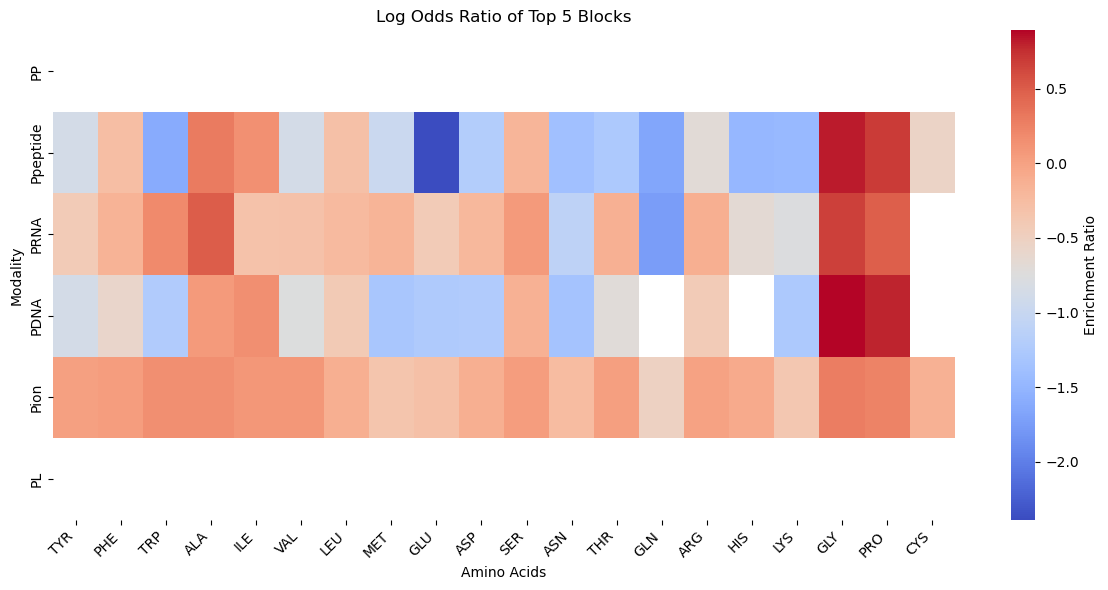

In [13]:
enrichment_df = pd.DataFrame(entropy_enrichment_ratios).T

# Group the amino acids by their type for ordering in the heatmap
enrichment_df = enrichment_df.reindex(columns=sorted(enrichment_df.columns, key=lambda x: AA_TYPE.get(x, '')))

dataset_order = ['PP', 'Ppeptide', 'PRNA', 'PDNA', 'Pion', 'PL']
enrichment_df = enrichment_df.reindex(dataset_order)

# Generate the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(enrichment_df, annot=False, cmap='coolwarm', cbar_kws={'label': 'Enrichment Ratio'})

plt.xlabel('Amino Acids')
plt.ylabel('Modality')
plt.title('Log Odds Ratio of Top 5 Blocks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
prot_topk_block_types = []
lig_topk_block_types = []
prot_all_block_types = []
lig_all_block_types = []
for idx, interact_scores_item in enumerate(interact_scores):
    raw_data_item = raw_data[idx]
    assert raw_data_item['id'] == interact_scores_item['id'], f"mismatch ids: {raw_data_item['id']} != {interact_scores_item['id']}"
    
    num_prot = len([block_idx for block_idx in range(len(raw_data_item['data']['B'])) if raw_data_item['data']['segment_ids'][block_idx] == 0])
    num_lig = len([block_idx for block_idx in range(len(raw_data_item['data']['B'])) if raw_data_item['data']['segment_ids'][block_idx] == 1])

    if num_prot < k:
        continue
    prot_all_signature = np.zeros(VOCAB_LEN)
    prot_all_block_types_count = Counter([raw_data_item['data']['B'][block_idx] for block_idx in range(len(raw_data_item['data']['B'])) if raw_data_item['data']['segment_ids'][block_idx] == 0])
    for prot_type, count in prot_all_block_types_count.items():
        if prot_type != VOCAB.abrv_to_idx('<G>'):
            prot_all_signature[prot_type] += count         
    prot_scores = [(score, block_id) for score, block_id in list(zip(interact_scores_item['cos_distances'], interact_scores_item['block_idx'])) if raw_data[idx]['data']['segment_ids'][block_id] == 0]
    prot_topk = [raw_data[idx]['data']["B"][i] for _, i in sorted(prot_scores)[:k]]
    prot_topk_signature = np.zeros(VOCAB_LEN)
    blocks, counts = np.unique(prot_topk, return_counts=True)
    prot_topk_signature[blocks] = counts

    prot_topk_block_types.append(prot_topk_signature)
    prot_all_block_types.append(prot_all_signature)
    
    if num_lig < k:
        continue
    lig_all_signature = np.zeros(VOCAB_LEN)
    lig_all_block_types_count = Counter([raw_data_item['data']['B'][block_idx] for block_idx in range(len(raw_data_item['data']['B'])) if raw_data_item['data']['segment_ids'][block_idx] != 0])
    for lig_type, count in lig_all_block_types_count.items():
        if lig_type != VOCAB.abrv_to_idx('<G>'):
            lig_all_signature[lig_type] += count         
    lig_scores = [(score, block_id) for score, block_id in list(zip(interact_scores_item['cos_distances'], interact_scores_item['block_idx'])) if raw_data[idx]['data']['segment_ids'][block_id] != 0]
    lig_topk = [raw_data[idx]['data']["B"][i] for _, i in sorted(lig_scores)[:k]]
    lig_topk_signature = np.zeros(VOCAB_LEN)
    blocks, counts = np.unique(lig_topk, return_counts=True)
    lig_topk_signature[blocks] = counts

    lig_topk_block_types.append(lig_topk_signature)
    lig_all_block_types.append(lig_all_signature)

In [15]:
lig_topk_block_types = np.array(lig_topk_block_types)
lig_all_block_types = np.array(lig_all_block_types)
prot_topk_block_types = np.array(prot_topk_block_types)
prot_all_block_types = np.array(prot_all_block_types)

In [16]:
def normalize_signatures(signatures):
    return signatures/np.sum(signatures, axis=1)[:, np.newaxis]

lig_topk_norm = normalize_signatures(lig_topk_block_types).mean(axis=0)
lig_all_norm = normalize_signatures(lig_all_block_types).mean(axis=0)
prot_topk_norm = normalize_signatures(prot_topk_block_types).mean(axis=0)
prot_all_norm = normalize_signatures(prot_all_block_types).mean(axis=0)

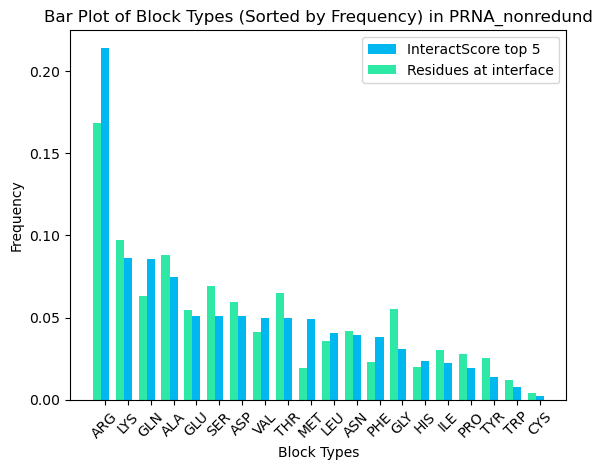

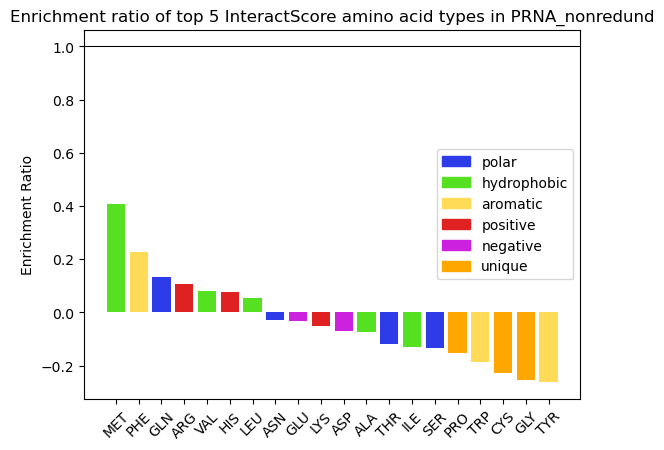

In [20]:
# Sort the dictionary by values in descending order
show_num_blocks = 20
sorted_topk_block_types = {k: v for v, k in sorted(zip(prot_topk_norm.tolist(), range(VOCAB_LEN)), key=lambda item: item[0], reverse=True)[:show_num_blocks]}

# Plot the bar plot
bar_width = 0.35


plt.bar(np.arange(len(sorted_topk_block_types)), sorted_topk_block_types.values(), width=bar_width, label=f"InteractScore top {k}", color = "#00b7f0")
plt.bar(np.arange(len(sorted_topk_block_types))-bar_width, prot_all_norm[list(sorted_topk_block_types.keys())], width=bar_width, label="Residues at interface", color="#2EE8A6")

plt.xticks(ticks=np.arange(len(sorted_topk_block_types)), labels=[VOCAB.idx_to_abrv(x) for x in sorted_topk_block_types.keys()], rotation=45)

# Add labels and title
plt.xlabel('Block Types')
plt.ylabel('Frequency')
plt.title(f'Bar Plot of Block Types (Sorted by Frequency) in {modality}')
plt.legend()
plt.savefig(f'block_types_{modality}_{k}.png')
plt.show()

enrichment_ratio = {VOCAB.idx_to_abrv(k): np.log10(prot_topk_norm[k]/prot_all_norm[k]) for k in sorted_topk_block_types}
sorted_enrichment = {k: v for k, v in sorted(enrichment_ratio.items(), key=lambda item: item[1], reverse=True)}
# plt.bar(sorted_enrichment.keys(), sorted_enrichment.values(), color = "#00b7f0")
fig, ax = plt.subplots()
for aa, ratio in sorted_enrichment.items():
    color = aa_type_color_dict[AA_TYPE[aa]]
    ax.bar(aa, ratio, color=color)
plt.xticks(rotation=45)
plt.axhline(y=1, color='black', linestyle='-', linewidth=0.75)
legend_patches = [mpatches.Patch(color=color, label=aa_type) for aa_type, color in aa_type_color_dict.items()]
plt.legend(handles=legend_patches)
plt.title(f'Enrichment ratio of top {k} InteractScore amino acid types in {modality}')
plt.ylabel('Enrichment Ratio')
plt.savefig(f'enrichment_ratio_{modality}_{k}.png')
plt.show()

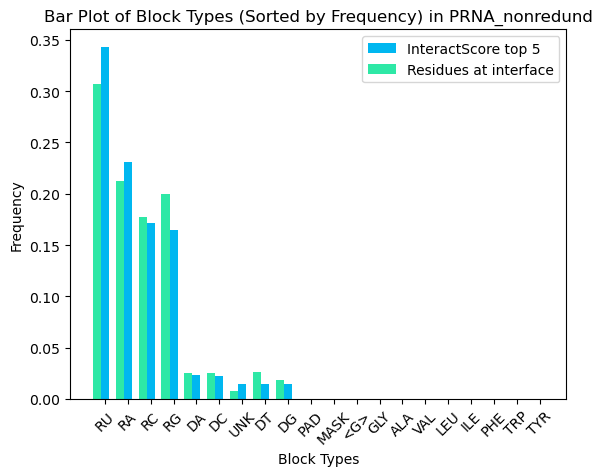

/tmp/ipykernel_1542834/2467253018.py:22: RuntimeWarning: invalid value encountered in scalar divide
  enrichment_ratio = {VOCAB.idx_to_abrv(k): lig_topk_norm[k]/lig_all_norm[k] for k in sorted_topk_block_types}


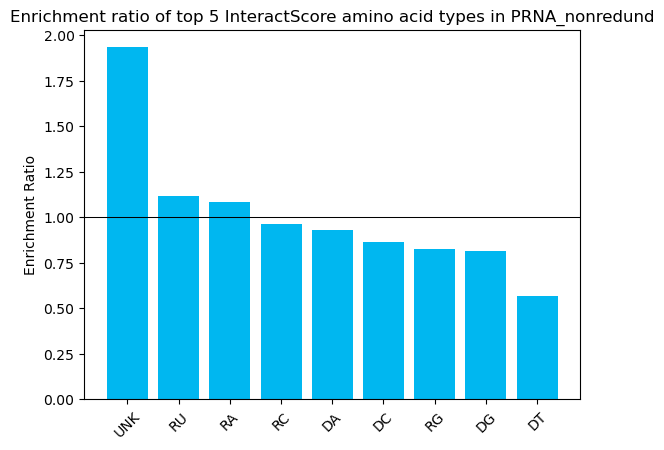

In [18]:
# Sort the dictionary by values in descending order
show_num_blocks = 20
sorted_topk_block_types = {k: v for v, k in sorted(zip(lig_topk_norm.tolist(), range(VOCAB_LEN)), key=lambda item: item[0], reverse=True)[:show_num_blocks]}

# Plot the bar plot
bar_width = 0.35


plt.bar(np.arange(len(sorted_topk_block_types)), sorted_topk_block_types.values(), width=bar_width, label=f"InteractScore top {k}", color = "#00b7f0")
plt.bar(np.arange(len(sorted_topk_block_types))-bar_width, lig_all_norm[list(sorted_topk_block_types.keys())], width=bar_width, label="Residues at interface", color="#2EE8A6")

plt.xticks(ticks=np.arange(len(sorted_topk_block_types)), labels=[VOCAB.idx_to_abrv(x) for x in sorted_topk_block_types.keys()], rotation=45)

# Add labels and title
plt.xlabel('Block Types')
plt.ylabel('Frequency')
plt.title(f'Bar Plot of Block Types (Sorted by Frequency) in {modality}')
plt.legend()
plt.savefig(f'block_types_{modality}_{k}.png')
plt.show()

enrichment_ratio = {VOCAB.idx_to_abrv(k): lig_topk_norm[k]/lig_all_norm[k] for k in sorted_topk_block_types}
sorted_enrichment = {k: v for k, v in sorted(enrichment_ratio.items(), key=lambda item: item[1], reverse=True)}
# plt.bar(sorted_enrichment.keys(), sorted_enrichment.values(), color = "#00b7f0")
plt.bar(sorted_enrichment.keys(), sorted_enrichment.values(), color = "#00b7f0")
plt.xticks(rotation=45)
plt.axhline(y=1, color='black', linestyle='-', linewidth=0.75)
plt.title(f'Enrichment ratio of top {k} InteractScore amino acid types in {modality}')
plt.ylabel('Enrichment Ratio')
plt.savefig(f'enrichment_ratio_{modality}_{k}.png')
plt.show()

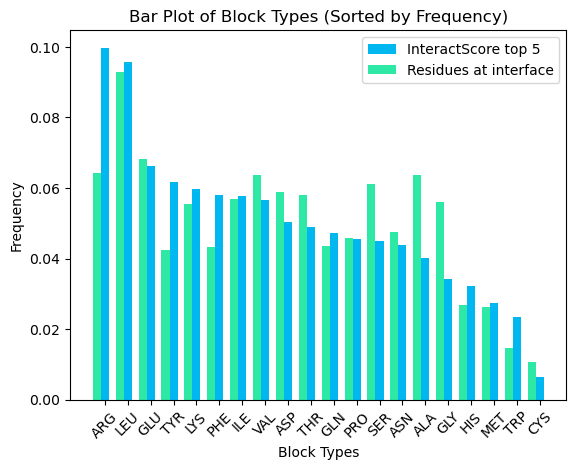

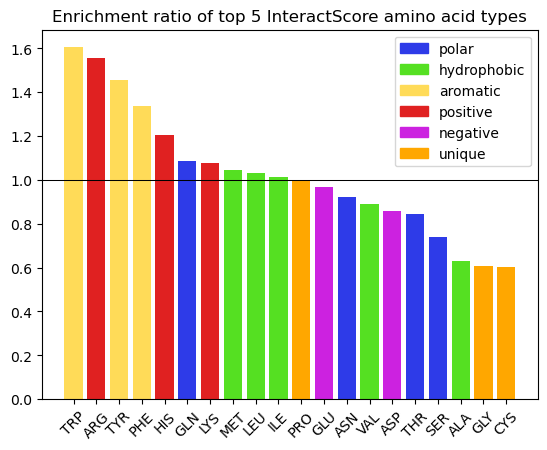

In [61]:
if modality == 'PP':
    # Sort the dictionary by values in descending order
    show_num_blocks = 20
    sorted_topk_block_types = {k: v for v, k in sorted(zip(lig_topk_norm.tolist(), range(VOCAB_LEN)), key=lambda item: item[0], reverse=True)[:show_num_blocks]}

    # Plot the bar plot
    bar_width = 0.35


    plt.bar(np.arange(len(sorted_topk_block_types)), sorted_topk_block_types.values(), width=bar_width, label=f"InteractScore top {k}", color = "#00b7f0")
    plt.bar(np.arange(len(sorted_topk_block_types))-bar_width, lig_all_norm[list(sorted_topk_block_types.keys())], width=bar_width, label="Residues at interface", color="#2EE8A6")

    plt.xticks(ticks=np.arange(len(sorted_topk_block_types)), labels=[VOCAB.idx_to_abrv(x) for x in sorted_topk_block_types.keys()], rotation=45)

    # Add labels and title
    plt.xlabel('Block Types')
    plt.ylabel('Frequency')
    plt.title(f'Bar Plot of Block Types (Sorted by Frequency) in {modality}')
    plt.legend()
    plt.savefig(f'block_types_{modality}_{k}.png')
    plt.show()

    enrichment_ratio = {VOCAB.idx_to_abrv(k): lig_topk_norm[k]/lig_all_norm[k] for k in sorted_topk_block_types}
    sorted_enrichment = {k: v for k, v in sorted(enrichment_ratio.items(), key=lambda item: item[1], reverse=True)}
    # plt.bar(sorted_enrichment.keys(), sorted_enrichment.values(), color = "#00b7f0")
    fig, ax = plt.subplots()
    for aa, ratio in sorted_enrichment.items():
        color = aa_type_color_dict[AA_TYPE[aa]]
        ax.bar(aa, ratio, color=color)
    plt.xticks(rotation=45)
    plt.axhline(y=1, color='black', linestyle='-', linewidth=0.75)
    legend_patches = [mpatches.Patch(color=color, label=aa_type) for aa_type, color in aa_type_color_dict.items()]
    plt.legend(handles=legend_patches)
    plt.title(f'Enrichment ratio of top {k} InteractScore amino acid types in {modality}')
    plt.ylabel('Enrichment Ratio')
    plt.savefig(f'enrichment_ratio_{modality}_{k}.png')
    plt.show()